# Emotion detection from text

A machine learning project that classifies text into 6 emotions (anger, fear, joy, love, sadness, surprise) using NLP preprocessing and classical ML models.

### Project steps:

1.**Data Loading:** Load the dataset (~1600 labeled text samples) from kaggle;
2.**Exploratory Data Analysis (EDA):** Inspect class distribuition, text lenght, missing values and duplicates;
3.**Text Cleaning:** Lowercase, remove URLs/mentions/hashtags/punctuation, tokenize;
4.**POS_Tagging & Lemmatization:** Tag part-of-speech before lemmatizing to improve accuracy;
5.**Stopword Removal:** Applied after lemmatization to preserve sentence context during POS tagging;
6.**Label Encoding:** Convert emotion labels to numeric format;
7.**Train/Validation/Test Split:** Stratified 70/15/15 split to preserve class balance;
8.**Feature Engineering (TF-IDF):** Vectorize cleaned text, fit only on training data to avoid data leakage;
9.**Model Training and Comparison:** Train and compare Logistic Regression, Linear SVM, Naive Bayes and Random Forest;
10.**Model Selection:** Choose Linear SVM based on F1 macro score (best performance/speed trade-off);
11.**Error Analysis:** Investigate missclassifications, compare SVM vs Logistic Regression predicions, inspect model coefficients to undestand specific failure patterns;
12.**Final Evaluation:** Evaluate the selected model once on the held-out test set;
13.**Model Export:** Save the trained model, vectorizer and label encoder for deployment;

In [44]:
#Importing the necessary libraries 

# core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text cleaning
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML prep
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder

# Downloading nlkt (only need once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\NATHALIA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\NATHALIA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\NATHALIA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\NATHALIA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\NATHALIA\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\NATHALIA\AppData\Roaming\nltk_data...
[nltk_data]   P

True

## Loading the dataset

You can obtain the dataset in one of two ways:

**Option 1: Manual download (used in this project)**
Download the dataset manually from [Kaggle](https://www.kaggle.com/datasets/abhrajaiswal/emotions-detection-text-dataset/data) and place it in the project root as `emotions.xlsx`.

**Option 2: Using kagglehub**
```python
import kagglehub
path = kagglehub.dataset_download("abhrajaiswal/emotions-detection-text-dataset")
print("Path to dataset files:", path)
```

In [45]:
# Reading the data base

df = pd.read_excel('data/emotions.xlsx')
df.head()
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     16000 non-null  object
 1   Emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB
(16000, 2)


In [46]:
# Checking for the existence of null data
print(df.isnull().sum())
print(df.duplicated().sum())

df = df.drop_duplicates()
print(df.duplicated().sum())

Text       0
Emotion    0
dtype: int64
1
0


Emotion
joy         5361
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


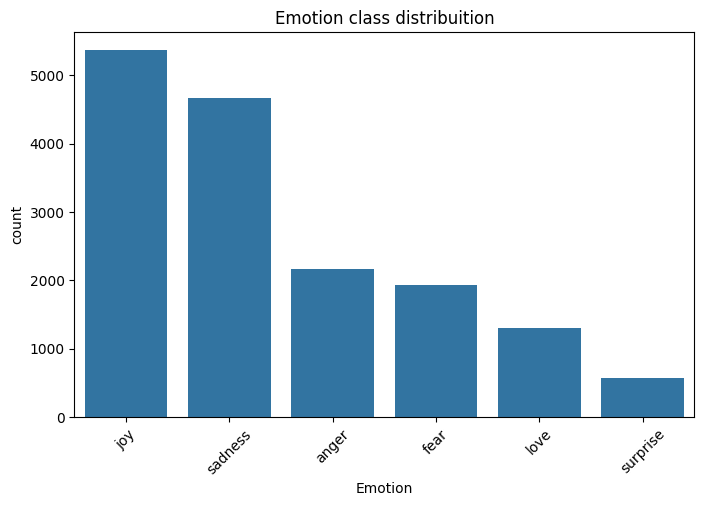

In [47]:
# Looking at class distribuition 
print(df['Emotion'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Emotion', order=df['Emotion'].value_counts().index)   
plt.title('Emotion class distribuition')
plt.xticks(rotation=45)
plt.show()


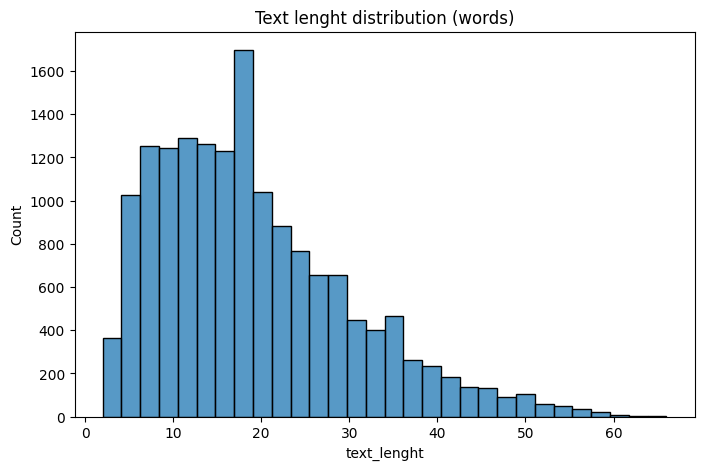

count    15999.000000
mean        19.166760
std         10.987102
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: text_lenght, dtype: float64

In [48]:
# Text lenght exploration
df['text_lenght'] = df['Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['text_lenght'], bins=30)
plt.title('Text lenght distribution (words)')
plt.show()

df['text_lenght'].describe()

In [49]:
# importing pos_tag
from nltk import pos_tag
from nltk.corpus import wordnet

# Cleaning the text
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)        # Remove mentions/hashtags
    text = re.sub(r'[^a-z\s]', '', text)         # Remove punctiations/numbers

    tokens = word_tokenize(text)

    pos_tags = pos_tag(tokens)

    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

    tokens_final = [word for word in lemmatized if word not in stop_words]
    return ' '.join(tokens_final)

df['clean_text'] = df['Text'].apply(clean_text)

# Comparing before/after in a few rows
df[['Text','clean_text']].sample(10)

,Text,clean_text
12924,i am feeling very lethargic although still try...,feel lethargic although still try get gym toda...
7260,im feeling indecisive about what i want to do ...,im feel indecisive want rest life
7196,i feel welcomed and acknowledged and can nod m...,feel welcome acknowledge nod head give h
10451,i was feeling some irritation and anger feelin...,feel irritation anger feeling insult
8717,i feel like if i m too fake with lighting you ...,feel like fake light take away immerse story
15814,i feel like a greedy ingrate for saying this b...,feel like greedy ingrate say felt kind bad pre...
5495,i got lots o crazy shit going on but i am love...,get lot crazy shit go love feel hopeful future
4068,i would feel myself being a little bit repress...,would feel little bit repress creativity idea ...
9436,i remembered seeing these pieces and feeling s...,remember see piece feel impress see surprised ...
6290,i feel like a very useful engine mother those ...,feel like useful engine mother watch thomas un...


In [50]:
# Encoding the labels
le = LabelEncoder()
df['emotions_encoded'] = le.fit_transform(df['Emotion'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [51]:
# Train/test split (stratified)
# Stratifying keeps class proportions consistent across splits - Important given the imbalance you'll likely see

X = df['clean_text']
y = df['emotions_encoded']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}, val: {len(X_val)}, Test: {len(X_test)}")

Train: 11199, val: 2400, Test: 2400


In [52]:
# vectorization with TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# max_features limits the vocanulary to the N most relevant words (prevents dimentional explosion)
tfidf = TfidfVectorizer(max_features=5000)

# fit_transform only in train
X_train_tfidf = tfidf.fit_transform(X_train)

# Only transform() in validation and test
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(11199, 5000)


In [53]:
# training the model

from sklearn.linear_model import LogisticRegression

# class_weight = 'balanced' helps compensate class imbalance
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


              precision    recall  f1-score   support

       anger       0.82      0.86      0.84       324
        fear       0.84      0.81      0.83       291
         joy       0.91      0.86      0.89       804
        love       0.69      0.86      0.77       195
     sadness       0.93      0.85      0.89       700
    surprise       0.60      0.91      0.73        86

    accuracy                           0.85      2400
   macro avg       0.80      0.86      0.82      2400
weighted avg       0.87      0.85      0.86      2400



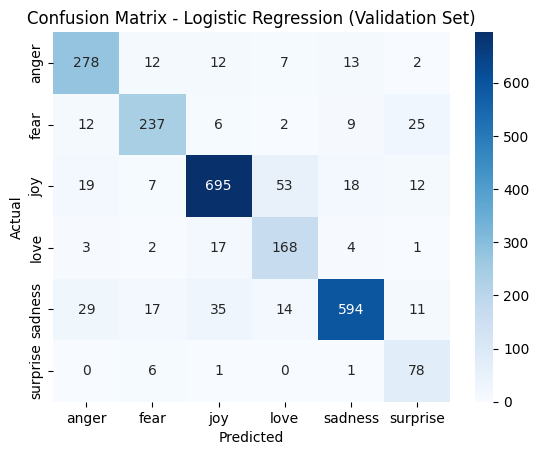

In [54]:
# Evaluating on the validation set

from sklearn.metrics import classification_report, confusion_matrix

y_val_pred = model.predict(X_val_tfidf)

print(classification_report(y_val, y_val_pred, target_names=le.classes_))


# confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.Figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Validation Set)')
plt.show()

### Training additional models:

- Linear SVC
- Multinomial Naive Bayes 
- Random Forest

In [55]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time

# Dictionary of models

models = {
    'Logistic Regression' : model,
    'Linear SVM' : LinearSVC(class_weight='balanced', random_state=42),
    'Naive Bayes' : MultinomialNB(),
    'Random Forest' : RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200, n_jobs=-1)
}

results = {}

for name, m in models.items():
    start = time.time()

    if name != 'Logistic Regression': # This model has already been trained and tested
        m.fit(X_train_tfidf, y_train)

    train_time = time.time() - start

    preds = m.predict(X_val_tfidf)

    results[name] = {
        'accuracy': accuracy_score(y_val, preds),
        'f1_macro': f1_score(y_val, preds, average='macro'),
        'f1_weighted' : f1_score(y_val, preds, average='weighted'),
        'precision_macro' : precision_score(y_val, preds, average='macro'),
        'recall_macro' : recall_score(y_val, preds, average='macro'),
        'train_time_sec' : round(train_time, 2)
    }

results_df = pd.DataFrame(results).T.sort_values('f1_macro', ascending=False)
results_df


,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,train_time_sec
Linear SVM,0.865833,0.825695,0.866981,0.813697,0.841865,0.15
Logistic Regression,0.854167,0.821383,0.856903,0.798122,0.858995,0.00
Random Forest,0.832917,0.798656,0.833907,0.790214,0.810055,4.98
Naive Bayes,0.706250,0.489716,0.656652,0.862025,0.472101,0.01


<Figure size 1000x600 with 0 Axes>

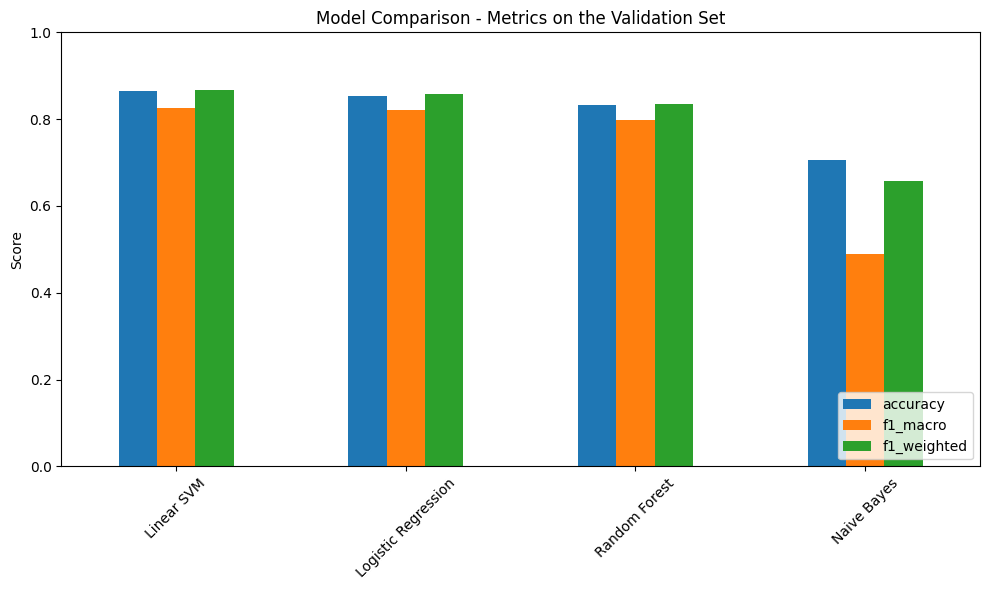

In [56]:
# Viewing the comparison between the models
plt.figure(figsize=(10,6))
results_df.sort_values('f1_macro', ascending=False)[['accuracy', 'f1_macro', 'f1_weighted']].plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison - Metrics on the Validation Set')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [57]:
predictions = {}
for name, m in models.items():
    predictions[name] = m.predict(X_val_tfidf)

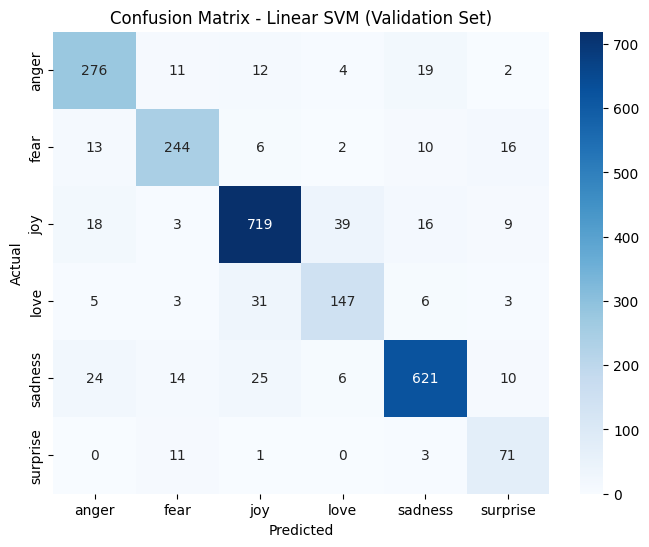

In [58]:
# Error Analysis
# Comparing SVM vs Logistic Regression

from sklearn.metrics import confusion_matrix

svm_preds = models['Linear SVM'].predict(X_val_tfidf)
lr_preds = models['Logistic Regression'].predict(X_val_tfidf)

# SVM's confusion matrix (best model)
cm_svm = confusion_matrix(y_val, svm_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM (Validation Set)')
plt.show()

In [59]:
# Exemples where SVM got it right and Logistic Regression got it wrong
import numpy as np

y_val_array = y_val.values if hasattr(y_val, 'values') else np.array(y_val)
X_val_array = X_val.values if hasattr(X_val, 'values') else np.array(X_val)

svm_right_lr_wrong = (svm_preds == y_val_array) & (lr_preds != y_val_array)

comparison = pd.DataFrame({
    'text' : X_val_array[svm_right_lr_wrong],
    'actual' : le.inverse_transform(y_val_array[svm_right_lr_wrong]),
    'lr_predicted' : le.inverse_transform(lr_preds[svm_right_lr_wrong]),
    'svm_predicted' : le.inverse_transform(svm_preds[svm_right_lr_wrong])
})

print(f"Examples where SVM got it wright and Logistic Regression got it wrong: {len(comparison)}")
comparison.sample(min(10, len(comparison)))

Examples where SVM got it wright and Logistic Regression got it wrong: 90


,text,actual,lr_predicted,svm_predicted
67,think almost make counsellor cry yesterday say...,joy,love,joy
28,want wonderful feel passionate career,joy,love,joy
83,want say front embarrass feeling come mouth du...,sadness,love,sadness
69,im get ready feel stress general take toll mil...,sadness,anger,sadness
89,could feel sweet spirit happy help,joy,love,joy
65,ive ever write although im gon na reproduce fu...,surprise,fear,surprise
43,would experience number time later life first ...,sadness,joy,sadness
75,imdoing good almost strange feel carefree,joy,surprise,joy
10,write something big happen like fun trip miles...,joy,love,joy
88,feel heartbroken confused blah blah blah,sadness,fear,sadness


In [60]:
# Evaluating the SVM (the chosen model) on the test set

from sklearn.metrics import classification_report, confusion_matrix

# Using the pre-trained model (no need to train it again)
svm_test_preds = models['Linear SVM'].predict(X_test_tfidf)

print(classification_report(y_test, svm_test_preds, target_names=le.classes_))

              precision    recall  f1-score   support

       anger       0.88      0.83      0.85       324
        fear       0.83      0.86      0.84       290
         joy       0.91      0.86      0.88       804
        love       0.68      0.78      0.72       196
     sadness       0.90      0.92      0.91       700
    surprise       0.73      0.79      0.76        86

    accuracy                           0.86      2400
   macro avg       0.82      0.84      0.83      2400
weighted avg       0.87      0.86      0.87      2400



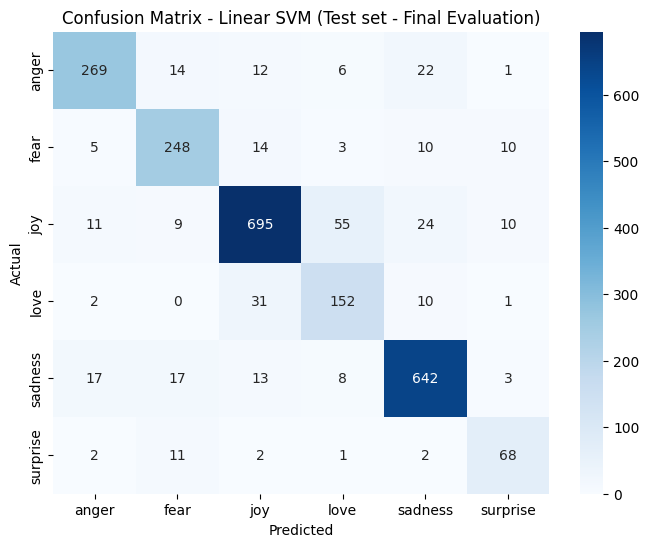

In [61]:
cm_test = confusion_matrix(y_test, svm_test_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM (Test set - Final Evaluation)')
plt.show()

In [62]:
# Saving the model and the vectorizer
import joblib

joblib.dump(models['Linear SVM'], 'emotion_svm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print('Files saved successfully!')

Files saved successfully!


In [63]:
# Reloading (simulating a fresh environment like de demo)
loaded_model = joblib.load('emotion_svm_model.pkl')
loaded_tfidf = joblib.load('tfidf_vectorizer.pkl')
loaded_le = joblib.load('label_encoder.pkl')

# Quick test with a new sentence
new_text = 'I am so happy today, everithing feels amazing'
new_text_clean = clean_text(new_text)
vector = loaded_tfidf.transform([new_text_clean])
new_text_prediction = loaded_model.predict(vector)
predicted_emotion = loaded_le.inverse_transform(new_text_prediction)

print(f'Text: {new_text}')
print(f'Clean_text: {new_text_clean}')
print(f'Predicted emotion: {predicted_emotion[0]}')


# Results
# Text: I am so happy today, everithing feels amazing
# Clean_text: happy today everithing feel amaze
# Predicted emotion: surprise




Text: I am so happy today, everithing feels amazing
Clean_text: happy today everithing feel amaze
Predicted emotion: surprise


In [64]:
# Diagnostic Test (comparing with the correct spelling)
right_text = 'I am so happy today, everything feels amazing'
misspelled_text = 'I am so happy today, everithing feels amazing'

for text in [right_text, misspelled_text]:
    clean = clean_text(text)
    vector = loaded_tfidf.transform([clean])
    pred = loaded_model.predict(vector)
    emotion = loaded_le.inverse_transform(pred)
    print(f'Text: {text}')
    print(f'Prediction: {pred}')
    print(f'Emotion: {emotion[0]}\n')


# Even with the spelling corrected the result is still "surprise". So the spelling wasn't the cause - the problem is actually related to the sentences vocabulary.

Text: I am so happy today, everything feels amazing
Prediction: [5]
Emotion: surprise

Text: I am so happy today, everithing feels amazing
Prediction: [5]
Emotion: surprise



In [65]:
# Isolating wich word is causing this

# Running a diagnostic block to find out exactly wich word (or combination) is 'pulling' the prediction towards 'surprise'

test_words = ['amaze', 'happy', 'happy today', 'feel amaze', 'happy today, feel amaze', 'today', 'feel']

for t in test_words:
    vector = loaded_tfidf.transform([t])
    pred = loaded_model.predict(vector)
    emotion = loaded_le.inverse_transform(pred)
    print(f"'{t}' -> {emotion[0]}")

'amaze' -> surprise
'happy' -> joy
'happy today' -> joy
'feel amaze' -> surprise
'happy today, feel amaze' -> surprise
'today' -> joy
'feel' -> joy


In [66]:
feature_names = tfidf.get_feature_names_out()
surprise_idx = list(le.classes_).index('surprise')

coefs = models['Linear SVM'].coef_[surprise_idx]

top_indices = np.argsort(coefs)[-15:][::-1]
top_words = [(feature_names[i], coefs[i]) for i in top_indices]

for word, weight in top_words:
    print(f'{word}: {weight:.3f}')

impressed: 4.950
curious: 4.935
funny: 4.466
daze: 4.408
shock: 4.162
amaze: 4.077
impress: 4.060
surprise: 3.898
surprised: 3.785
shocked: 3.548
amazed: 3.536
stun: 3.503
dazed: 3.205
stunned: 3.125
overwhelmed: 2.979
